# Kernel benchmark results

Analyze cache-hot core and full-memory compression benchmarks. Choose a result directory, select the implementations to compare, and optionally save plots as vector PDFs for LaTeX.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from pernix_benchmark_tools.results import (
    CP2K_BENCHMARK_RE,
    PERNIX_BENCHMARK_RE,
    load_benchmark_contexts,
    load_benchmark_results,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)


def find_repository_root() -> Path:
    for start in (Path.cwd().resolve(), Path.cwd().resolve().parent):
        for candidate in (start, *start.parents):
            if (candidate / "benchmark-tools" / "pyproject.toml").is_file():
                return candidate
    raise FileNotFoundError("Could not find the pernix-benchmark checkout")


REPOSITORY_ROOT = find_repository_root()
DEFAULT_RESULTS_ROOT = REPOSITORY_ROOT / "benchmark-results"
ALL_RESULTS = pd.DataFrame()
CONTEXTS = pd.DataFrame()
RESULT_DIR: Path | None = None

## Select results and implementations

Choose a discovered folder or type any other directory path into the folder field. Click **Load folder**, then select one or more implementations. Relative paths are resolved from the current working directory.

In [2]:
def discover_result_directories(root: Path) -> tuple[str, ...]:
    if not root.is_dir():
        return ()
    return tuple(
        str(path)
        for path in sorted(
            {
                file.parent.resolve()
                for file in root.rglob("benchmark_*_results.json")
                if not file.name.startswith("benchmark_pcie_")
            }
        )
    )


discovered_directories = discover_result_directories(DEFAULT_RESULTS_ROOT)
result_directory = widgets.Combobox(
    options=discovered_directories,
    value=discovered_directories[0] if discovered_directories else str(DEFAULT_RESULTS_ROOT),
    description="Results folder:",
    ensure_option=False,
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)
refresh_folders = widgets.Button(description="Refresh folders", icon="refresh")
load_folder = widgets.Button(description="Load folder", button_style="primary", icon="folder-open")
implementation_selector = widgets.SelectMultiple(
    options=(),
    description="Implementations:",
    rows=7,
    layout=widgets.Layout(width="60%"),
    style={"description_width": "initial"},
)
select_all = widgets.Button(description="Select all")
clear_selection = widgets.Button(description="Clear")
save_pdfs = widgets.Checkbox(
    value=False,
    description="Save plots as vector PDF when plot cells run",
    indent=False,
    style={"description_width": "initial"},
)
pdf_directory = widgets.Text(
    value=str(DEFAULT_RESULTS_ROOT / "plots"),
    description="PDF folder:",
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)
load_output = widgets.Output()


def refresh_directory_options(_button: widgets.Button) -> None:
    result_directory.options = discover_result_directories(DEFAULT_RESULTS_ROOT)


def load_result_folder(_button: widgets.Button) -> None:
    global ALL_RESULTS, CONTEXTS, RESULT_DIR
    with load_output:
        load_output.clear_output()
        try:
            directory = Path(result_directory.value).expanduser()
            if not directory.is_absolute():
                directory = (Path.cwd() / directory).resolve()
            else:
                directory = directory.resolve()
            loaded_results = load_benchmark_results(directory, family="kernel")
            loaded_contexts = load_benchmark_contexts(directory, family="kernel")
            loaded_results = loaded_results[
                loaded_results["benchmark_schema"] != "pcie_v1"
            ].copy()
            loaded_contexts = loaded_contexts[
                ~loaded_contexts["source_file"].str.startswith("benchmark_pcie_")
            ].copy()
            if loaded_results.empty:
                raise ValueError("No kernel benchmark results found in this folder")
        except Exception as error:
            display(Markdown(f"> **Could not load results:** `{error}`"))
            return

        required = [
            "implementation",
            "direction",
            "value_type",
            "memory_mode",
            "bit_width",
            "blocks",
        ]
        if loaded_results[required].isna().any().any():
            display(Markdown("> **Invalid results:** one or more benchmark dimensions are missing."))
            return

        ALL_RESULTS = loaded_results
        CONTEXTS = loaded_contexts
        RESULT_DIR = directory
        implementations = tuple(sorted(ALL_RESULTS["implementation"].unique()))
        implementation_selector.options = implementations
        implementation_selector.value = implementations
        pdf_directory.value = str(directory / "plots")
        display(Markdown(
            f"Loaded **{len(ALL_RESULTS):,} rows** from **{ALL_RESULTS['source_file'].nunique()} files** "
            f"in `{directory}`. Select implementations, then run the cells below."
        ))


refresh_folders.on_click(refresh_directory_options)
load_folder.on_click(load_result_folder)
select_all.on_click(lambda _button: setattr(
    implementation_selector, "value", tuple(implementation_selector.options)
))
clear_selection.on_click(lambda _button: setattr(implementation_selector, "value", ()))

display(widgets.VBox([
    result_directory,
    widgets.HBox([refresh_folders, load_folder]),
    implementation_selector,
    widgets.HBox([select_all, clear_selection]),
    save_pdfs,
    pdf_directory,
    load_output,
]))

In [5]:
def selected_results() -> pd.DataFrame:
    if ALL_RESULTS.empty:
        raise RuntimeError("Select a result folder and click 'Load folder' first")
    selected = list(implementation_selector.value)
    if not selected:
        raise ValueError("Select at least one implementation")
    return ALL_RESULTS[ALL_RESULTS["implementation"].isin(selected)].copy()


def selected_kernel_results() -> pd.DataFrame:
    results = selected_results()
    return results[results["benchmark_schema"] != "pcie_v1"].copy()



def selected_contexts() -> pd.DataFrame:
    selected = list(implementation_selector.value)
    return CONTEXTS[CONTEXTS["implementation"].isin(selected)].copy()


def finish_figure(figure: plt.Figure, filename: str) -> None:
    if save_pdfs.value:
        output_directory = Path(pdf_directory.value).expanduser()
        if not output_directory.is_absolute():
            output_directory = (Path.cwd() / output_directory).resolve()
        output_directory.mkdir(parents=True, exist_ok=True)
        safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "-", filename).strip("-")
        destination = output_directory / f"{safe_name}.pdf"
        figure.savefig(destination, format="pdf", bbox_inches="tight")
        display(Markdown(f"Saved vector PDF: `{destination}`"))
    display(figure)
    plt.close(figure)


display(Markdown(
    "The implementation selector is live. After changing it, rerun the analysis cells "
    "you want to refresh. This notebook only uses kernel benchmark rows. Enable PDF "
    "export before running plot cells."
))

The implementation selector is live. After changing it, rerun the analysis cells you want to refresh. This notebook only uses kernel benchmark rows. Enable PDF export before running plot cells.

## Load and normalize

Pernix and CP2K use different benchmark-name shapes. The reusable loader applies the two anchored expressions below and fails if a name is not fully matched, preventing partially parsed rows from silently entering a plot.

In [6]:
display(Markdown(f"**Pernix regex:** `{PERNIX_BENCHMARK_RE.pattern}`"))
display(Markdown(f"**CP2K regex:** `{CP2K_BENCHMARK_RE.pattern}`"))

results = selected_results()
assert (results["bytes_per_second"] > 0).all()

pd.DataFrame(
    {"value": [
        len(results),
        results["source_file"].nunique(),
        results["implementation"].nunique(),
        int(results["bit_width"].min()),
        int(results["bit_width"].max()),
        int(results["blocks"].min()),
        int(results["blocks"].max()),
    ]},
    index=[
        "rows",
        "result files",
        "selected implementations",
        "minimum bit width",
        "maximum bit width",
        "minimum blocks",
        "maximum blocks",
    ],
)

**Pernix regex:** `^BM_(?P<direction>compress|decompress)_(?P<implementation>[A-Za-z0-9]+?)(?P<value_type>f32|f64)_(?P<core_throughput>true|false)_(?P<bit_width>\d+)/(?P<blocks>\d+)$`

**CP2K regex:** `^BM_cp2k_(?P<direction>compression|decompression)/width(?P<bit_width>\d+)/(?P<blocks>\d+)/manual_time$`

,value
rows,8832
result files,2
selected implementations,2
minimum bit width,1
maximum bit width,24
minimum blocks,1
maximum blocks,4194304


## Run context and data quality

Host names, dates, frequencies, and load averages make cross-machine and cross-run differences visible. The optional `machinestate.json` is used when available.

In [7]:
if RESULT_DIR is None:
    raise RuntimeError("Load a result folder first")

machine_state_path = RESULT_DIR / "machinestate.json"
if machine_state_path.is_file():
    try:
        machine_state = json.loads(machine_state_path.read_text(encoding="utf-8"))
        cpu_name = machine_state.get("CpuInfo", {}).get("Name", "unknown CPU")
        display(Markdown(f"**Host CPU:** {cpu_name}"))
    except (OSError, json.JSONDecodeError) as error:
        display(Markdown(f"> Could not read `machinestate.json`: `{error}`"))
else:
    display(Markdown("No `machinestate.json` was found; benchmark context is shown below."))

contexts = selected_contexts()
context_columns = [
    column
    for column in ["implementation", "host_name", "date", "mhz_per_cpu", "load_avg", "library_version"]
    if column in contexts.columns
]
context_summary = contexts[context_columns].copy()
if "load_avg" in context_summary:
    load_values = context_summary.pop("load_avg").apply(
        lambda value: value if isinstance(value, list) and len(value) == 3 else [pd.NA] * 3
    )
    context_summary[["load_1m", "load_5m", "load_15m"]] = pd.DataFrame(
        load_values.tolist(), index=context_summary.index
    )
context_summary

**Host CPU:** AMD EPYC 9655 96-Core Processor

,implementation,host_name,date,mhz_per_cpu,library_version,load_1m,load_5m,load_15m
0,avx2,cn1302,2026-07-17T13:31:54+02:00,2600,v1.9.4,1.16,1.18,2.28
1,avx512vbmi,cn1302,2026-07-17T14:57:19+02:00,2600,v1.9.4,1.42,1.37,1.27


## Benchmark coverage

This kernel-only table excludes PCIe E2E rows. Each cell is the number of measurements available for a normalized benchmark family among the selected implementations.

In [8]:
kernel_results = selected_kernel_results()
if kernel_results.empty:
    display(Markdown("> No kernel benchmark rows are present for the selected implementations."))
else:
    coverage = (
        kernel_results.groupby(
            ["implementation", "direction", "value_type", "memory_mode"],
            observed=True,
        )
        .size()
        .unstack(["direction", "value_type", "memory_mode"], fill_value=0)
    )
    display(coverage)

direction      compression                decompression               
value_type             f32       f64                f32       f64     
memory_mode           core full core full          core full core full
implementation                                                        
avx2                   552  552  552  552           552  552  552  552
avx512vbmi             552  552  552  552           552  552  552  552

## Peak reported throughput

For each bit width, this view selects the highest reported bytes/second across all tested block counts.

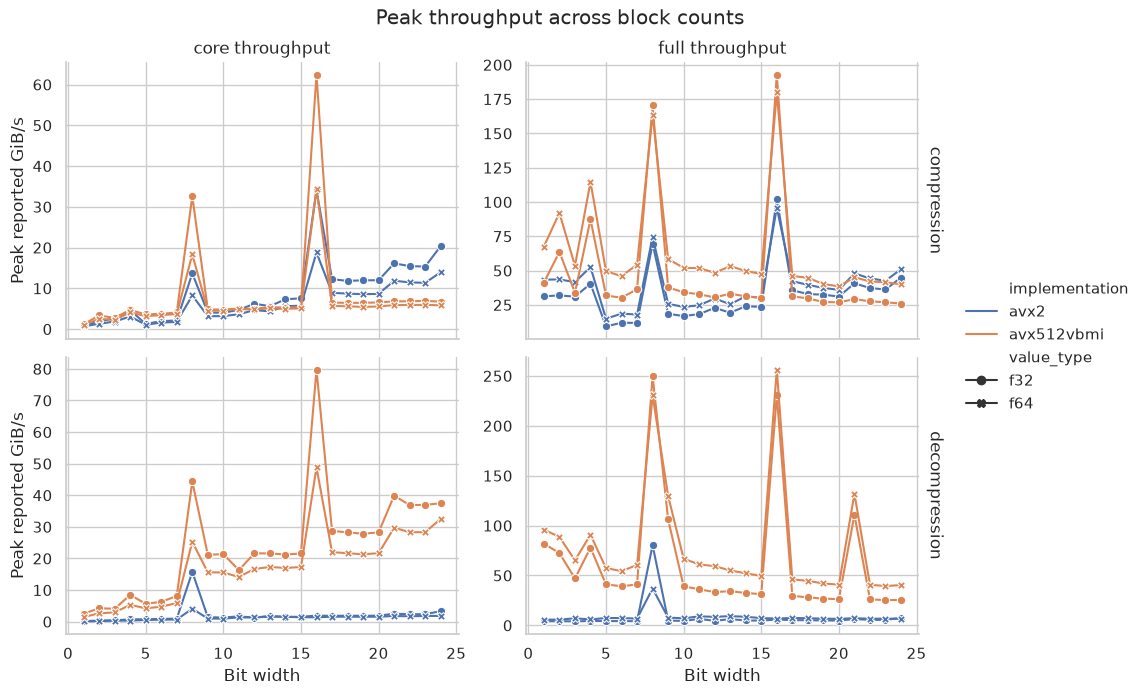

In [9]:
kernel_results = selected_kernel_results()
if kernel_results.empty:
    display(Markdown("> No kernel benchmark rows are present for the selected implementations."))
else:
    cp2k_schemas = set(
        kernel_results.loc[kernel_results["implementation"] == "cp2k", "benchmark_schema"]
    )
    if "cp2k_legacy" in cp2k_schemas:
        display(Markdown(
            "> **Legacy CP2K caveat:** these rows use the old byte-accounting formula. "
            "Their absolute GiB/s values and speedups are provisional."
        ))
    elif cp2k_schemas:
        display(Markdown(
            "> **CP2K accounting:** corrected `pernix_v1` rows use the same logical-byte "
            "formula as matching Pernix full-throughput benchmarks."
        ))

    peak = (
        kernel_results.groupby(
            ["implementation", "direction", "value_type", "memory_mode", "bit_width"],
            as_index=False,
            observed=True,
        )["gib_per_second"]
        .max()
    )
    grid = sns.relplot(
        data=peak,
        x="bit_width",
        y="gib_per_second",
        hue="implementation",
        style="value_type",
        row="direction",
        col="memory_mode",
        kind="line",
        markers=True,
        dashes=False,
        facet_kws={"sharey": False, "margin_titles": True},
        height=3.4,
        aspect=1.45,
    )
    grid.set_axis_labels("Bit width", "Peak reported GiB/s")
    grid.set_titles(row_template="{row_name}", col_template="{col_name} throughput")
    grid.figure.suptitle("Peak throughput across block counts", y=1.02)
    finish_figure(grid.figure, "peak-throughput")

## Scaling with block count

The plots prefer widths 8, 16, and 24 when available and otherwise choose representative widths from the loaded result set.

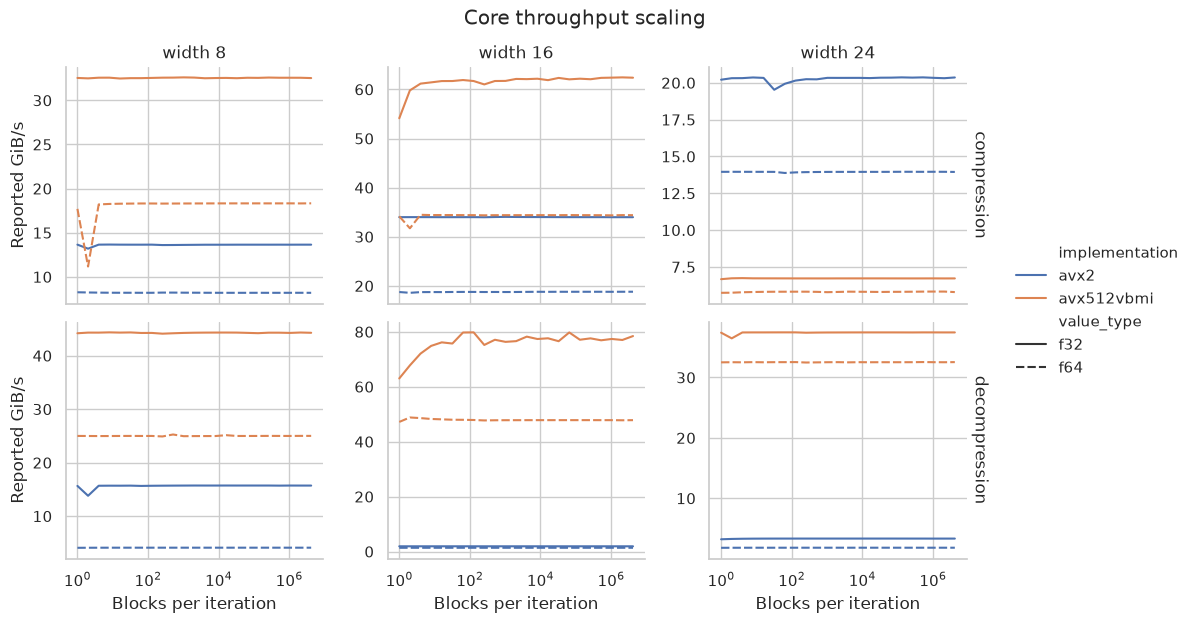

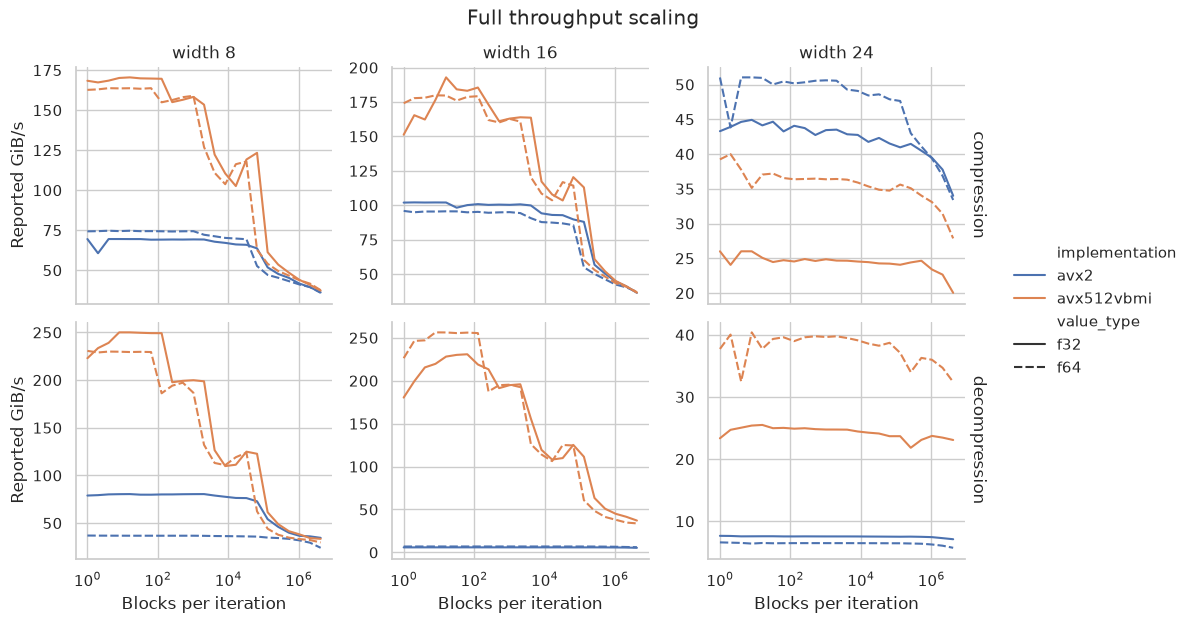

In [10]:
kernel_results = selected_kernel_results()
if kernel_results.empty:
    display(Markdown("> No kernel benchmark rows are present for the selected implementations."))
else:
    available_widths = sorted(kernel_results["bit_width"].unique())
    representative_widths = [width for width in (8, 16, 24) if width in available_widths]
    if not representative_widths:
        indices = sorted({0, len(available_widths) // 2, len(available_widths) - 1})
        representative_widths = [available_widths[index] for index in indices]
    scaling = kernel_results[kernel_results["bit_width"].isin(representative_widths)]

    for memory_mode in sorted(scaling["memory_mode"].unique()):
        subset = scaling[scaling["memory_mode"] == memory_mode]
        widths = [width for width in representative_widths if width in set(subset["bit_width"])]
        if subset.empty:
            continue
        grid = sns.relplot(
            data=subset,
            x="blocks",
            y="gib_per_second",
            hue="implementation",
            style="value_type",
            row="direction",
            col="bit_width",
            col_order=widths,
            kind="line",
            facet_kws={"sharey": False, "margin_titles": True},
            height=3.0,
            aspect=1.15,
        )
        grid.set(xscale="log")
        grid.set_axis_labels("Blocks per iteration", "Reported GiB/s")
        grid.set_titles(row_template="{row_name}", col_template="width {col_name}")
        grid.figure.suptitle(f"{memory_mode.title()} throughput scaling", y=1.03)
        finish_figure(grid.figure, f"throughput-scaling-{memory_mode}")

## Matched speedup over fallback

Rows are matched on direction, value type, memory mode, bit width, and block count. Select `fallback` together with at least one other implementation to generate these heatmaps.

In [11]:
results = selected_kernel_results()
if results.empty:
    display(Markdown("> No kernel benchmark rows are present for the selected implementations."))
elif "fallback" not in set(results["implementation"]):
    display(Markdown("> Select `fallback` to calculate matched speedups."))
else:
    match_keys = ["direction", "value_type", "memory_mode", "bit_width", "blocks"]
    fallback = (
        results[results["implementation"] == "fallback"][match_keys + ["bytes_per_second"]]
        .rename(columns={"bytes_per_second": "fallback_bytes_per_second"})
    )
    speedups = results.merge(fallback, on=match_keys, how="inner", validate="many_to_one")
    speedups["speedup_over_fallback"] = (
        speedups["bytes_per_second"] / speedups["fallback_bytes_per_second"]
    )
    best_speedups = (
        speedups[speedups["implementation"] != "fallback"]
        .groupby(
            ["implementation", "direction", "value_type", "memory_mode", "bit_width"],
            as_index=False,
            observed=True,
        )["speedup_over_fallback"]
        .max()
    )

    if best_speedups.empty:
        display(Markdown("> Select at least one non-fallback implementation for comparison."))
    for (direction, value_type, memory_mode), subset in best_speedups.groupby(
        ["direction", "value_type", "memory_mode"], observed=True
    ):
        matrix = subset.pivot(
            index="implementation", columns="bit_width", values="speedup_over_fallback"
        )
        figure, axis = plt.subplots(figsize=(12, max(2.0, 0.65 * len(matrix))))
        sns.heatmap(matrix, cmap="RdYlGn", center=1.0, annot=True, fmt=".1f", ax=axis)
        axis.set_title(f"Best speedup over fallback: {direction}, {value_type}, {memory_mode}")
        axis.set_xlabel("Bit width")
        axis.set_ylabel("Implementation")
        finish_figure(
            figure,
            f"speedup-{direction}-{value_type}-{memory_mode}",
        )

> Select `fallback` to calculate matched speedups.

## Winners and optimal block counts

The first table records each selected implementation's optimal tested block count. The second chooses the highest-throughput implementation from only the selected implementations.

In [12]:
results = selected_kernel_results()
if results.empty:
    display(Markdown("> No kernel benchmark rows are present for the selected implementations."))
else:
    configuration = [
        "implementation",
        "direction",
        "value_type",
        "memory_mode",
        "bit_width",
    ]
    optimal_rows = results.loc[
        results.groupby(configuration, observed=True)["bytes_per_second"].idxmax()
    ].copy()
    optimal_blocks = optimal_rows[
        configuration + ["blocks", "gib_per_second"]
    ].sort_values(configuration)
    display(Markdown("### Optimal tested block count per selected implementation (first 30 rows)"))
    display(optimal_blocks.head(30))

    comparison_keys = ["direction", "value_type", "memory_mode", "bit_width"]
    winners = optimal_rows.loc[
        optimal_rows.groupby(comparison_keys, observed=True)["bytes_per_second"].idxmax()
    ][comparison_keys + ["implementation", "blocks", "gib_per_second"]].sort_values(
        comparison_keys
    )
    display(Markdown("### Winning selected implementation by matched configuration"))
    display(winners)

    display(Markdown("### Number of wins"))
    display(winners["implementation"].value_counts().rename("wins").to_frame())

### Optimal tested block count per selected implementation (first 30 rows)

,implementation,direction,value_type,memory_mode,bit_width,blocks,gib_per_second
50,avx2,compression,f32,core,1,1024,0.942096
120,avx2,compression,f32,core,2,2,1.866861
295,avx2,compression,f32,core,3,8192,2.669435
420,avx2,compression,f32,core,4,32768,4.613196
510,avx2,compression,f32,core,5,1024,1.287297
575,avx2,compression,f32,core,6,1,1.945439
690,avx2,compression,f32,core,7,1,2.128228
820,avx2,compression,f32,core,8,8,13.659873
945,avx2,compression,f32,core,9,32,4.075909
1050,avx2,compression,f32,core,10,8,4.023731


### Winning selected implementation by matched configuration

,direction,value_type,memory_mode,bit_width,implementation,blocks,gib_per_second
31,compression,f32,core,1,avx512vbmi,64,1.177183
121,compression,f32,core,2,avx512vbmi,2,3.357943
341,compression,f32,core,3,avx512vbmi,4194304,2.742239
346,compression,f32,core,4,avx512vbmi,1,4.708658
521,compression,f32,core,5,avx512vbmi,4096,3.594231
...,...,...,...,...,...,...,...
21516,decompression,f64,full,20,avx512vbmi,4,40.838552
21646,decompression,f64,full,21,avx512vbmi,32,131.997324
21751,decompression,f64,full,22,avx512vbmi,8,40.721106
21866,decompression,f64,full,23,avx512vbmi,8,39.464810


### Number of wins

,wins
implementation,
avx512vbmi,158
avx2,34
